# Data visualization

In [3]:
import pandas as pd
import chess
import chess.svg
from IPython.display import SVG
import os
import matplotlib.pyplot as plt
import seaborn
import numpy as np


DATASET_DIR = os.path.join("..", "dataset")
MAIN_DATASET = os.path.join(DATASET_DIR, "chessData.csv")
df = pd.read_csv(MAIN_DATASET)

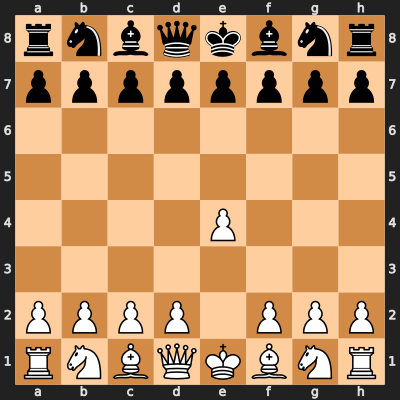

In [20]:
board = chess.Board(df.iloc[0]["FEN"])

SVG(chess.svg.board(board=board, size=400))

In [18]:
def get_turn(df):
    df["black_turn"] = df["FEN"].str.contains(" b ", regex=False)
    df["white_turn"] = df["FEN"].str.contains(" w ", regex=False)
    return df

df = get_turn(df)

True


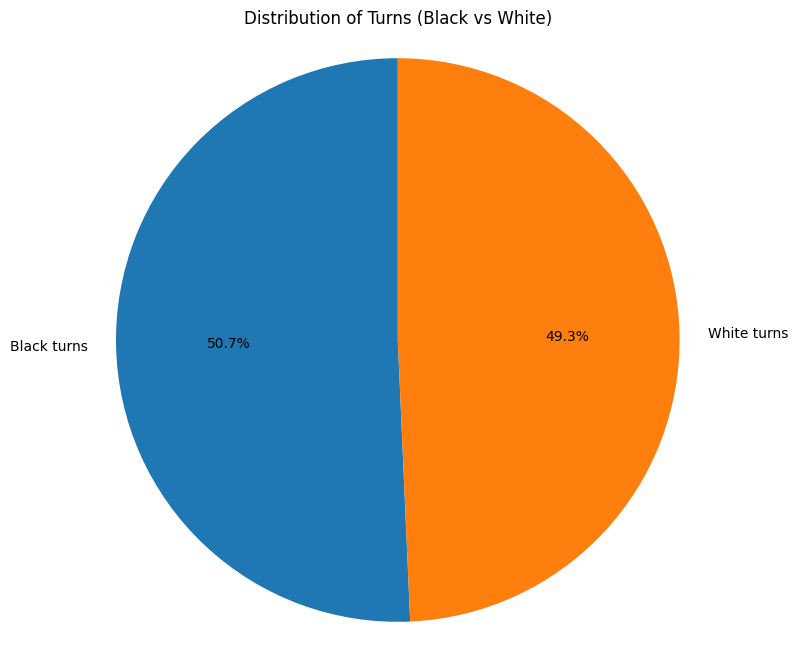

In [19]:
sample = df.sample(1000).copy()
print(sample.iloc[0]["black_turn"])

black_total = sample["black_turn"].sum()
white_total = sample["white_turn"].sum()

values = [black_total, white_total]
labels = ["Black turns", "White turns"]

plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Turns (Black vs White)")
plt.axis("equal")

plt.show()